Task 2: Exploratory Data Analysis(EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

print("Titles data loaded:", titles.shape)
print("Credits data loaded:", credits.shape)

Titles data loaded: (5850, 15)
Credits data loaded: (77801, 5)


In [2]:
# Pehli 5 rows dekho
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [3]:
# Data ke baare mein basic info - columns, data types, kitne non-null values
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

In [4]:
# Numeric columns ka statistical summary
titles.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


In [5]:
# Missing values check karo har column mein
titles.isnull().sum()

,0
id,0
title,1
type,0
description,18
release_year,0
age_certification,2619
runtime,0
genres,0
production_countries,0
seasons,3744


In [6]:
# Movies aur Shows kitne hain dataset mein
titles['type'].value_counts()

,count
type,
MOVIE,3744
SHOW,2106


In [7]:
# Movies aur Shows kitne hain dataset mein
titles['type'].value_counts()

,count
type,
MOVIE,3744
SHOW,2106


In [8]:
# Sabse zyada genres kaunse hain
titles['genres'].value_counts().head(10)

,count
genres,
['comedy'],484
['documentation'],329
['drama'],328
"['comedy', 'drama']",135
"['drama', 'romance']",124
['reality'],113
"['drama', 'comedy']",109
"['comedy', 'documentation']",104
"['comedy', 'romance']",69


In [9]:
# Movies vs Shows ka average IMDb score compare karo
titles.groupby('type')['imdb_score'].mean()

,imdb_score
type,
MOVIE,6.246748
SHOW,6.977927


In [11]:
# Sabse zyada IMDb votes wali top 10 movies/shows
titles.sort_values('imdb_votes', ascending=False)[['title','type','imdb_score','imdb_votes']].head(10)

,title,type,imdb_score,imdb_votes
237,Inception,MOVIE,8.8,2294231.0
97,Forrest Gump,MOVIE,8.8,2021343.0
216,Breaking Bad,SHOW,9.5,1775990.0
645,The Dark Knight Rises,MOVIE,8.4,1669067.0
94,Se7en,MOVIE,8.6,1606270.0
651,Django Unchained,MOVIE,8.4,1472668.0
239,The Departed,MOVIE,8.5,1296244.0
102,Titanic,MOVIE,7.9,1146825.0
109,Léon: The Professional,MOVIE,8.5,1137357.0
36,GoodFellas,MOVIE,8.7,1131681.0


In [12]:
# Duplicate rows check karo
print("Total duplicate rows:", titles.duplicated().sum())

# Runtime mein outliers check karo (bahut zyada ya bahut kam runtime)
titles[titles['runtime'] == 0].shape[0], titles['runtime'].max()

Total duplicate rows: 0


(14, 240)

In [13]:
# Genres column mein top genres nikalne ke liye (kyunki ek row mein multiple genres list format mein hain)
from collections import Counter
import ast

all_genres = []
for g in titles['genres'].dropna():
    try:
        genre_list = ast.literal_eval(g)
        all_genres.extend(genre_list)
    except:
        pass

genre_counts = Counter(all_genres)
print(genre_counts.most_common(10))

[('drama', 2968), ('comedy', 2325), ('thriller', 1228), ('action', 1157), ('romance', 971), ('documentation', 952), ('crime', 936), ('animation', 705), ('family', 682), ('fantasy', 630)]


Task 3: Data Visualization

/tmp/ipykernel_3436/3949059735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titles, x='type', palette='Set2')


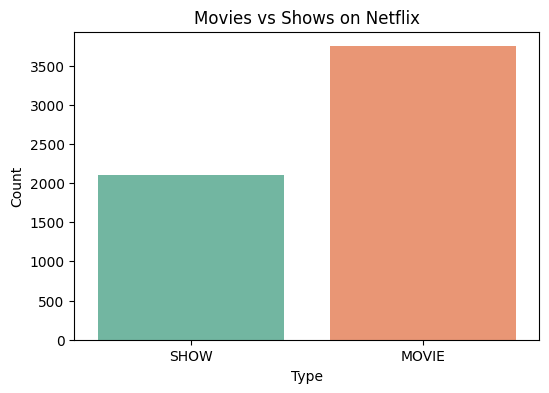

In [14]:
# Movies vs Shows count - Bar chart
plt.figure(figsize=(6,4))
sns.countplot(data=titles, x='type', palette='Set2')
plt.title('Movies vs Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

Ye chart Netflix ke catalog mein Movies aur Shows ki total count compare karta hai. Netflix par Movies (3700+) ki sankhya Shows (2100) se kaafi zyada hai, jo dikhata hai ki platform primarily movie-focused content library rakhta hai.

/tmp/ipykernel_3436/1731480060.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Count', y='Genre', palette='viridis')


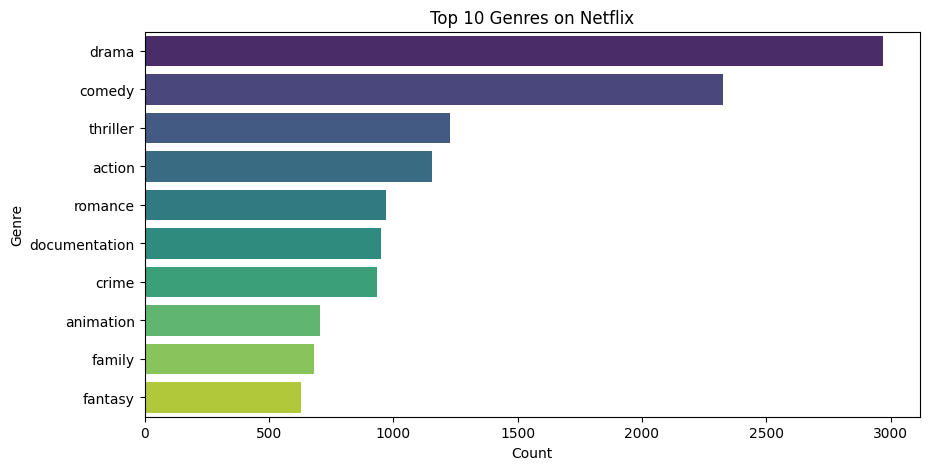

In [15]:
# Top 10 Genres - Bar chart
genre_df = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(10,5))
sns.barplot(data=genre_df, x='Count', y='Genre', palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Ye chart Netflix ke catalog mein Movies aur Shows ki total count compare karta hai. Netflix par Movies (3700+) ki sankhya Shows (2100) se kaafi zyada hai, jo dikhata hai ki platform primarily movie-focused content library rakhta hai.

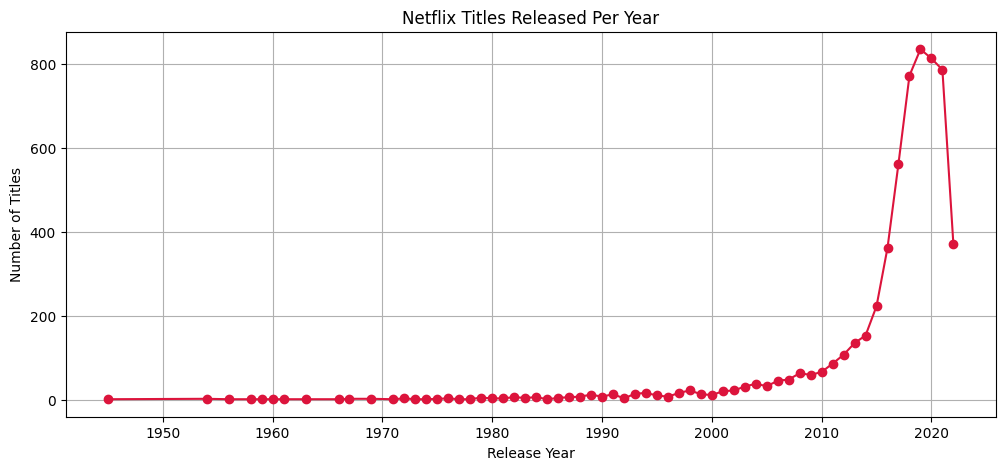

In [16]:
# Release Year Trend - Line chart
year_counts = titles['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values, marker='o', color='crimson')
plt.title('Netflix Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

Ye chart har saal Netflix par release hone waale titles ki trend dikhata hai. 2015 se pehle growth bahut slow thi, lekin 2015 ke baad content sharply badhna shuru hua aur 2019-2020 mein peak par pahuch gaya. Uske baad thoda decline dikh raha hai, jo shaayad recent years ka data abhi incomplete hone ki wajah se ho sakta hai.

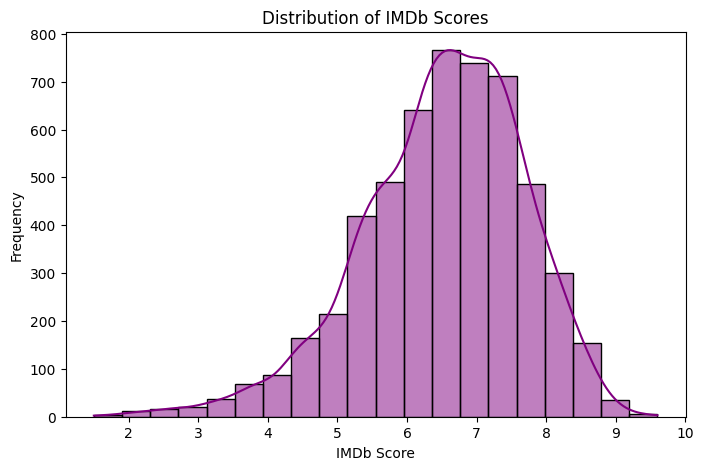

In [17]:
# IMDb Score Distribution - Histogram
plt.figure(figsize=(8,5))
sns.histplot(titles['imdb_score'].dropna(), bins=20, kde=True, color='purple')
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Frequency')
plt.show()

Ye histogram Netflix titles ke IMDb scores ki overall distribution dikhata hai. Zyadatar titles ka score 6 se 8 ke beech aata hai, jisme peak 7 ke aas-paas hai. Ye ek normal (bell-shaped) distribution dikhata hai, jiska matlab hai ki content ka average quality decent-to-good hai, bahut kam titles hi extreme low ya extreme high scores par hain.

/tmp/ipykernel_3436/1965724794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titles, x='type', y='imdb_score', palette='Set3')


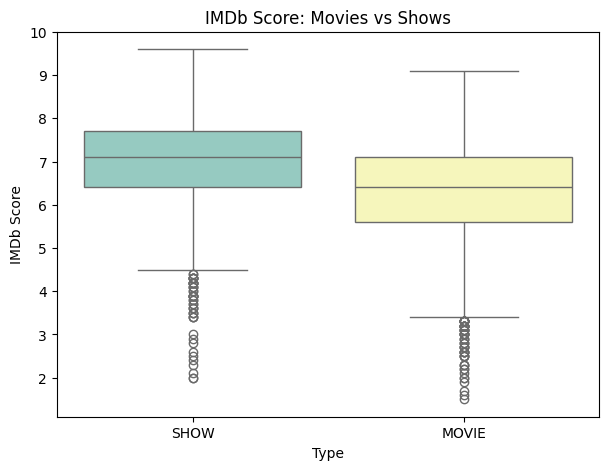

In [18]:
# Movies vs Shows - IMDb Score Comparison (Box plot)
plt.figure(figsize=(7,5))
sns.boxplot(data=titles, x='type', y='imdb_score', palette='Set3')
plt.title('IMDb Score: Movies vs Shows')
plt.xlabel('Type')
plt.ylabel('IMDb Score')
plt.show()

Ye boxplot Movies aur Shows ke IMDb scores ki comparison dikhata hai. Shows ka median score Movies ke median score se thoda better hai. Dono categories mein kuch outliers bhi hain jinka score bahut low hai, lekin overall Shows thoda better rated dikhte hain viewers dwara.

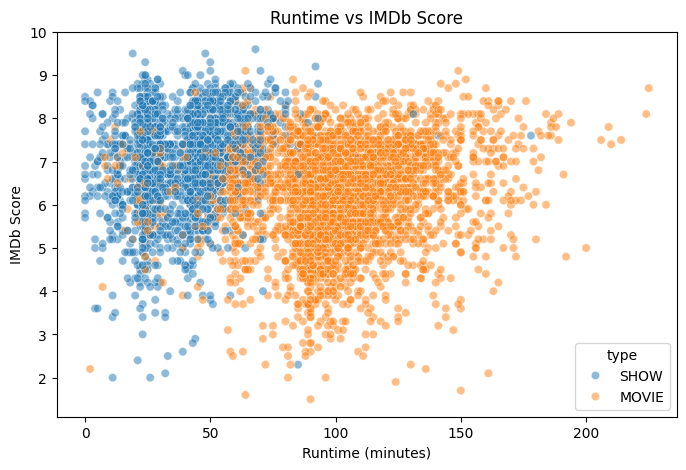

In [19]:
# Runtime vs IMDb Score - Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=titles, x='runtime', y='imdb_score', hue='type', alpha=0.5)
plt.title('Runtime vs IMDb Score')
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Score')
plt.show()]'[;]'

Ye scatter plot Movies aur Shows ke runtime aur unke IMDb score ke beech relationship dikhata hai. Shows (blue) generally kam runtime (20-60 minutes) ke hote hain, jabki Movies (orange) ka runtime zyada spread hua hai (80-150+ minutes). Runtime aur IMDb score ke beech koi strong direct pattern nahi dikhta — matlab lambi ya chhoti duration se rating directly affect nahi hoti.